# Introduction to Machine Learning — Class 6
## Evaluation, Class Imbalance, Nonlinear SVM & K-NN

**Input dataset:** `adult_classification_v1.csv`  
**Problem:** Binary classification  

---

### Learning goals
- Understand why accuracy can be misleading
- Build and interpret a confusion matrix
- Use appropriate classification metrics
- Deal with class imbalance
- Apply Nonlinear SVM and K-NN classifiers

> **Key idea:** Not all errors have the same cost.

<div style="margin-left: 2em; font-size: 0.9em; font-style: italic;">
An AI language model (ChatGPT by OpenAI) was used to support the creation of practical class materials. 
All arguments, outputs, and final wording were critically reviewed, edited, and validated by the author 
prior to use with students.
</div>

## 0. Data context

You will continue working with the **same binary classification dataset**.

- Target: `income`
- Strong class imbalance is expected

The data has not changed.  
What changes now is **how we evaluate and model it**.


In [1]:
DATA_PATH = "adult_classification_v1.csv"


## 1. Imports


In [9]:
# TODO: import required libraries
# numpy, pandas, matplotlib, seaborn
# sklearn: train_test_split
# sklearn.metrics: confusion_matrix, classification_report
# sklearn: SVC, KNeighborsClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score



In [10]:
# Auto-check
import importlib
_required = ["numpy", "pandas", "sklearn", "matplotlib"]
missing = [m for m in _required if importlib.util.find_spec(m) is None]
assert not missing, f"Missing packages: {missing}"
print("Auto-check passed.")


Auto-check passed.


## 2. Load data and split

### Tasks
- Load the dataset
- Create training and validation sets
- Verify if data scaling is needed

**Reflection**
- Is class imbalance visible?


In [ ]:
# TODO: load dataset and split
df = pd.read_csv(DATA_PATH)
X = df.drop("income", axis=1)
y = df["income"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


## 3. Confusion matrix

### Tasks
- Train a baseline classifier (e.g. Logistic Regression or Linear SVM)
- Compute the confusion matrix

**Reflection**
- Which errors are more frequent?


In [6]:
# TODO: baseline model and confusion matrix

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

scaler = StandardScaler()
svc = SVC(random_state=42)
base = make_pipeline(scaler, svc, verbose=True)
base.fit(X_train, y_train)


[Pipeline] .... (step 1 of 2) Processing standardscaler, total=   0.1s
[Pipeline] ............... (step 2 of 2) Processing svc, total=  52.3s


,steps,"[('standardscaler', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,True
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [11]:
y_pred = base.predict(X_test)
base_cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", base_cm)

Confusion Matrix:
 [[6323  480]
 [ 926 1316]]


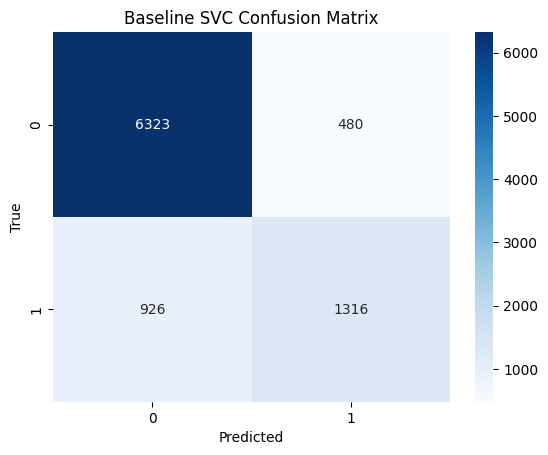

In [8]:
sns.heatmap(base_cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Baseline SVC Confusion Matrix")
plt.show()

## 4. Classification metrics

### Tasks
- Compute:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - Balanced accuracy

**Reflection**
- Which metric is most appropriate here?


In [12]:
# TODO: classification metrics
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.93      0.90      6803
           1       0.73      0.59      0.65      2242

    accuracy                           0.84      9045
   macro avg       0.80      0.76      0.78      9045
weighted avg       0.84      0.84      0.84      9045



In [14]:
balanced_accuracy_score(y_test, y_pred)

0.758209403601785

## 5. Nonlinear Support Vector Machine

Nonlinear SVM uses kernels to model complex decision boundaries.

### Tasks
- Train an SVM with an RBF kernel
- Compare results with linear models
- Evaluate the impact of parameter C on RBF nonlinear SVM

**Reflection**
- What changes when the boundary becomes nonlinear?


In [21]:
# TODO: nonlinear SVM
# different C
for C in [0.1, 1.0, 10.0]:
    print(f"Training RBF SVC with C={C}...")    
    sve_rbf = make_pipeline(StandardScaler(), SVC(kernel="rbf", class_weight="balanced" , C=C, random_state=42), verbose=True)
    sve_rbf.fit(X_train, y_train)
    y_pred_rbf = sve_rbf.predict(X_test)
    print("RBF SVC Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))
    print("RBF SVC Classification Report:\n", classification_report(y_test, y_pred_rbf))
    print("RBF SVC Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_rbf))


[Pipeline] .... (step 1 of 2) Processing standardscaler, total=   0.1s
[Pipeline] ............... (step 2 of 2) Processing svc, total= 1.5min
RBF SVC Confusion Matrix:
 [[5332 1471]
 [ 388 1854]]
RBF SVC Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.78      0.85      6803
           1       0.56      0.83      0.67      2242

    accuracy                           0.79      9045
   macro avg       0.74      0.81      0.76      9045
weighted avg       0.84      0.79      0.81      9045

RBF SVC Balanced Accuracy: 0.805356048644646


## 6. k-Nearest Neighbors (K-NN)

K-NN:
- is a lazy learning algorithm
- relies on distance and local neighborhoods

### Tasks
- Train K-NN classifiers with different K values
- Observe performance changes

**Reflection**
- How does K affect bias and variance?


In [24]:
# TODO: Train K-NN classifiers with different K values and Observe performance changes
balance_accuracies = {}
for k in [1, 3, 5, 7, 9, 21, 31, 41, 51, 71, 101, 151]:
    knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k), verbose=True)
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    print(f"K-NN (k={k}) Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
    print(f"K-NN (k={k}) Classification Report:\n", classification_report(y_test, y_pred_knn))
    balance_accuracy = balanced_accuracy_score(y_test, y_pred_knn)
    # save balanced accuracy for later comparison
    balance_accuracies[k] = balance_accuracy
    print(f"K-NN (k={k}) Balanced Accuracy:", balance_accuracy)
    print("-" * 50)


[Pipeline] .... (step 1 of 2) Processing standardscaler, total=   0.1s
[Pipeline]  (step 2 of 2) Processing kneighborsclassifier, total=   0.0s
K-NN (k=1) Confusion Matrix:
 [[5856  947]
 [ 946 1296]]
K-NN (k=1) Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86      6803
           1       0.58      0.58      0.58      2242

    accuracy                           0.79      9045
   macro avg       0.72      0.72      0.72      9045
weighted avg       0.79      0.79      0.79      9045

K-NN (k=1) Balanced Accuracy: 0.7194260075479635
--------------------------------------------------
[Pipeline] .... (step 1 of 2) Processing standardscaler, total=   0.0s
[Pipeline]  (step 2 of 2) Processing kneighborsclassifier, total=   0.0s
K-NN (k=3) Confusion Matrix:
 [[6071  732]
 [ 933 1309]]
K-NN (k=3) Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.89      0.88   

In [25]:
balance_accuracies

{1: 0.7194260075479635,
 3: 0.7381270568174323,
 5: 0.7422886187982083,
 7: 0.744503625217557,
 9: 0.7440525464771734,
 21: 0.7484623656745863,
 31: 0.7445774172411473,
 41: 0.7380289078531366,
 51: 0.7349776683241624,
 71: 0.7298407469129626,
 101: 0.7257580253660982,
 151: 0.7296328769788949}

## 7. Handling class imbalance

### Tasks
- Apply one technique to address imbalance:
  - class weighting
  - resampling (conceptual or practical)

**Reflection**
- How do metrics change after addressing imbalance?


In [ ]:
# TODO: apply class imbalance techniques (e.g., class_weight="balanced" for SVM, or oversampling/undersampling) and compare results




## 8. Critical reflection

Answer in Markdown:
- Why is accuracy misleading in imbalanced datasets?
- How do evaluation metrics affect decision-making?
- What are the ethical implications of different error types?


### Reflection

(Write your answers here.)
